In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

from torch.utils.data import DataLoader, WeightedRandomSampler

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time
from copy import deepcopy

In [7]:
#Config
print("Setting up configuration...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print(f"Using device: {device}")

# Define paths
base_path = Path('data/raw/chest_xray')

train_path = base_path / 'train'
test_path = base_path / 'test'
val_path = base_path / 'val'

print(f"Train path: {train_path}")
print(f"Test path:  {test_path}")
print(f"Val path:   {val_path}")

BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 0.01

IMG_SIZE = 224
NUM_CLASSES = 2
MODEL_NAME = 'resnet18'



Setting up configuration...
Using device: cpu
Train path: data\raw\chest_xray\train
Test path:  data\raw\chest_xray\test
Val path:   data\raw\chest_xray\val


In [11]:
#Load Data 

#Set Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#Dataset Acquisition

# NORMAL/ - label 0
# PNEUMONIA/ - label 1

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=test_transforms
)

val_dataset = datasets.ImageFolder(
    root=val_path,
    transform=test_transforms
)
print(f"Classes: {train_dataset.classes}")
print(f"Class index mapping: {train_dataset.class_to_idx}")
print(f"\nTraining samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")

class_counts = np.bincount(train_dataset.targets)
print(f"\nClass distribution:")
print(f"   NORMAL:    {class_counts[0]:,}")
print(f"   PNEUMONIA: {class_counts[1]:,}")
print(f"   Ratio:     {class_counts[1]/class_counts[0]:.1f}x more pneumonia")

# Weights Setup

class_weights = 1.0 / class_counts
sample_weights = class_weights[train_dataset.targets]
sample_weights = torch.tensor(sample_weights, dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f"\nClass weights:")
print(f"   NORMAL weight:    {class_weights[0]:.4f}")
print(f"   PNEUMONIA weight: {class_weights[1]:.4f}")
print(f"   Ratio:  {class_weights[0]/class_weights[1]:.1f}x more normal samples")

#Create Dataloaders

train_loader = DataLoader(
    train_dataset, 
    BATCH_SIZE, 
    sampler=sampler
)

test_loader = DataLoader(
    test_dataset,
    BATCH_SIZE,
    shuffle=False,
)

val_loader = DataLoader(
    val_dataset,
    BATCH_SIZE,
    shuffle=False,
)


Classes: ['NORMAL', 'PNEUMONIA']
Class index mapping: {'NORMAL': 0, 'PNEUMONIA': 1}

Training samples:   5,216
Validation samples: 16
Test samples:       624

Class distribution:
   NORMAL:    1,341
   PNEUMONIA: 3,875
   Ratio:     2.9x more pneumonia

Class weights:
   NORMAL weight:    0.0007
   PNEUMONIA weight: 0.0003
   Ratio:  2.9x more normal samples


In [8]:
#Load ResNet18

model = torchvision.models.resnet18(pretrained = True)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

print("\n Modified final layer:")
print(f"    Input features: {model.fc.in_features}")
print(f"    Output features: {model.fc.out_features}")



 Modified final layer:
    Input features: 512
    Output features: 2


In [36]:
# Training Components Setup
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=0.9,
    weight_decay = 1e-4,
)

print(f"Loss function: {criterion}")
print(f"Optimizer:     SGD")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Momentum:      0.9")
print(f"Weight decay:  1e-4")
print(f"\nTraining components ready")

Loss function: CrossEntropyLoss()
Optimizer:     SGD
Learning rate: 0.01
Momentum:      0.9
Weight decay:  1e-4

Training components ready


In [37]:
#Var Setup
train_losses, train_accuracies, val_losses, val_accuracies = [], [], [], []
start_time: float = time.time()
best_accuracy = 0
best_model = None

#Main Training Loop
for epoch in range(NUM_EPOCHS):
    print(f"epoch num: {epoch}")


    model.train()
    running_loss = 0.0
    running_corrects = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()   

        #forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        _, predicted = outputs.max(1)

        #backpropagation
        loss.backward()
        optimizer.step()

        #accumulation
        running_loss += loss.item() * images.size(0) #undoes averaging of loss 
        running_corrects += predicted.eq(labels).sum().item()

    #epoch averages
    epoch_loss = running_loss/ len(train_dataset)
    epoch_acc = running_corrects / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    model.eval()
    val_running_loss = 0
    val_running_corrects = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            _, predicted = outputs.max(1)

            val_running_loss += loss.item() * images.size(0)
            val_running_corrects += predicted.eq(labels).sum().item()
        
        val_epoch_loss = val_running_loss/ len(val_dataset)
        val_epoch_acc = val_running_corrects / len(val_dataset)
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_epoch_acc)
    print(f"Training loss: {epoch_loss}")
    print(f"Training accuracy: {epoch_acc}")
    print(f"Validation loss: {val_epoch_loss}")
    print(f"Validation acc: {val_epoch_acc}")

    if(val_epoch_acc> best_accuracy):
        best_accuracy = val_epoch_acc
        best_model = deepcopy(model.state_dict())
        print("\n Updated Best Model")

end_time: float = time.time()
total_unformatted_time = end_time - start_time
total_time: time.struct_time = time.strftime("%M:%S", time.gmtime(total_unformatted_time))

print("\n Final Training Stats:")
print(f"Total training time: {total_time}")
print(f"Best Validation Accuracy: {best_accuracy}")

#Load Best Model
if best_model is not None:
    model.load_state_dict(best_model)
    print("Loaded best model weights")



epoch num: 0
Training loss: 0.2532659287370193
Training accuracy: 0.9219708588957055
Validation loss: 0.24982821941375732
Validation acc: 0.875

 Updated Best Model
epoch num: 1
Training loss: 0.0671448418663449
Training accuracy: 0.9750766871165644
Validation loss: 0.9672320485115051
Validation acc: 0.625
epoch num: 2
Training loss: 0.05124876833238005
Training accuracy: 0.9800613496932515
Validation loss: 0.22285008430480957
Validation acc: 0.9375

 Updated Best Model
epoch num: 3
Training loss: 0.04729006441232914
Training accuracy: 0.9825536809815951
Validation loss: 0.06108478829264641
Validation acc: 1.0

 Updated Best Model
epoch num: 4
Training loss: 0.037893828337596434
Training accuracy: 0.9875383435582822
Validation loss: 0.07476218044757843
Validation acc: 1.0
epoch num: 5
Training loss: 0.03990129750001278
Training accuracy: 0.9852377300613497
Validation loss: 0.06397955119609833
Validation acc: 1.0
epoch num: 6
Training loss: 0.032056993998867814
Training accuracy: 0.9884

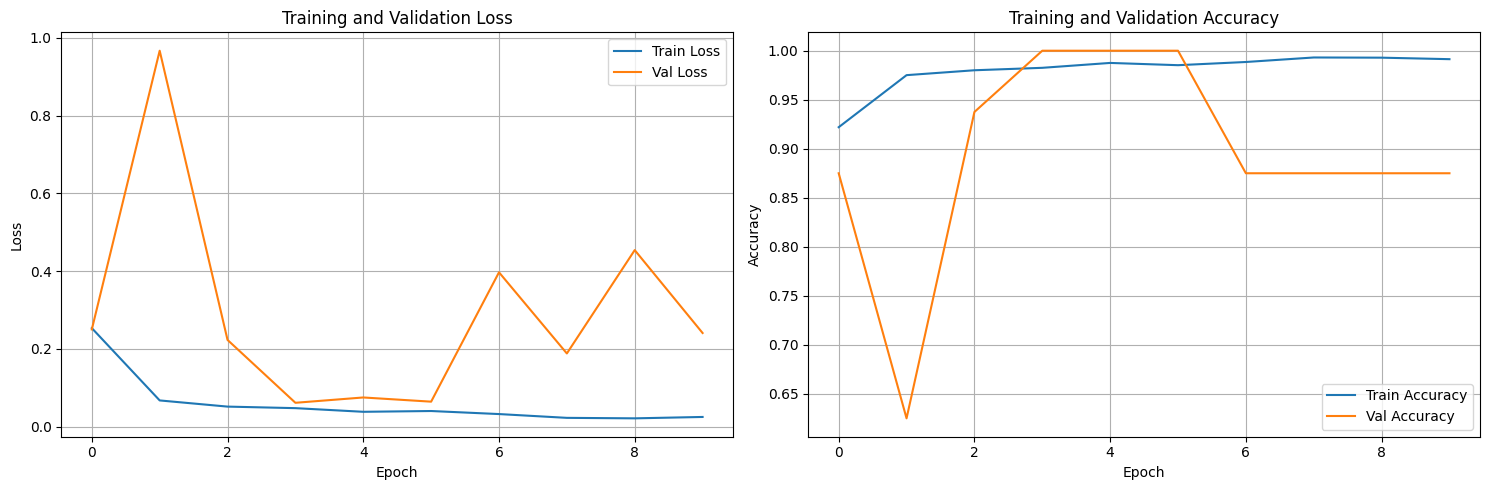

In [38]:
#Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss
ax1.plot(range(NUM_EPOCHS), train_losses, label='Train Loss')  
ax1.plot(range(NUM_EPOCHS), val_losses, label='Val Loss')    
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Plot 2: Accuracy
ax2.plot(range(NUM_EPOCHS), train_accuracies, label='Train Accuracy')
ax2.plot(range(NUM_EPOCHS), val_accuracies, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
#Save Trained Model
import os

os.makedirs('models', exist_ok=True)
model_path = 'models/resnet18_pneumonia.pth'
torch.save(model.state_dict(), 'models/resnet18_pneumonia.pth')

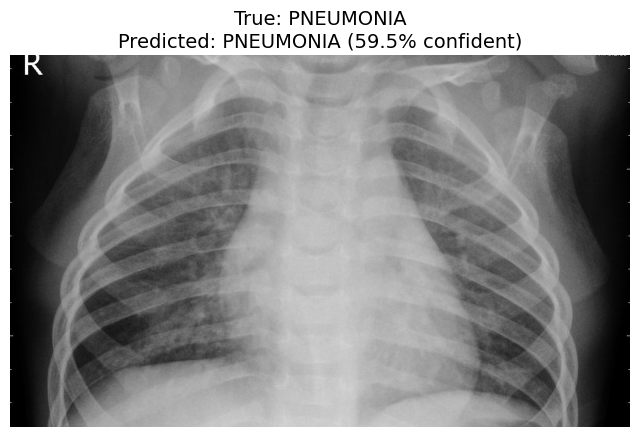


Prediction Results:
   True label:      PNEUMONIA
   Predicted:       PNEUMONIA
   Confidence:      59.5%
   Probabilities:   NORMAL: 40.5%, PNEUMONIA: 59.5%


In [42]:
#Test Single Prediction

import random
from PIL import Image

if model is None:
    torch.load(model_path)

model.eval()

class_names = ['NORMAL', 'PNEUMONIA']

test_normal = list((test_path / 'NORMAL').glob('*.jpeg'))
test_pneumonia = list((test_path / 'PNEUMONIA').glob('*.jpeg'))
all_test_images = test_normal + test_pneumonia

random_img_path = random.choice(all_test_images)

true_label = random_img_path.parent.name

img = Image.open(random_img_path).convert('RGB')
img_tensor = test_transforms(img)

img_tensor = img_tensor.unsqueeze(0)
img_tensor = img_tensor.to(device)

with torch.no_grad():
    outputs = model(img_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_percent = confidence.item() * 100

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title(f"True: {true_label}\nPredicted: {predicted_class} ({confidence_percent:.1f}% confident)", 
          fontsize=14)
plt.show()

print(f"\nPrediction Results:")
print(f"   True label:      {true_label}")
print(f"   Predicted:       {predicted_class}")
print(f"   Confidence:      {confidence_percent:.1f}%")
print(f"   Probabilities:   NORMAL: {probabilities[0][0].item()*100:.1f}%, PNEUMONIA: {probabilities[0][1].item()*100:.1f}%")